In [27]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:

# !pip install -q pandas numpy matplotlib seaborn textblob nltk yfinance pandas_ta scikit-learn



In [29]:
# from google.colab import files
# uploaded = files.upload()


In [30]:
!ls /content/drive/MyDrive


 certifcate.gdoc
 certifcate.jpg
 certificate_34.pdf
 Classroom
'Colab Notebooks'
'Copy of python.jpg'
'Copy of senita.jpg'
'Coursera BXLS28TI1T7I.gdoc'
'Coursera BXLS28TI1T7I.pdf'
 data
 Data-20251119T090255Z-1-001-week1
'docmntes for train crew.pdf'
'email list.gsheet'
'ML SVM.gslides'
 python.jpg
 reasumeSeniya.pdf
 Request_Letter.pdf.pdf
 senita.jpg
 seniya22.mp4
 seniyas.mp4
 seniya-solar-report1.pdf
 seniya-solar-report.pdf
 SeniyaSultanComputerScience-CV.pdf
'Seniya Sultan Computer Science  Resume (1).pdf'
'Seniya Sultan Computer Science  Resume (2).pdf'
'Seniya Sultan Computer Science  Resume (3).pdf'
'Seniya Sultan Computer Science  Resume (4).pdf'
'Seniya Sultan Computer Science  Resume (5).pdf'
'Seniya Sultan Computer Science  Resume.gdoc'
'Seniya Sultan Computer Science  Resume.pdf'
'SeniyaSultan-CV (1).pdf'
'SeniyaSultan-CV (2).pdf'
'SeniyaSultan-CV (3).pdf'
'SeniyaSultan-CV (4).pdf'
'SeniyaSultan-CV (5).pdf'
'Seniya Sultan CV.gdoc'
'Seniya Sultan-Cv.pdf'
'Seniya Sultan CV

In [31]:
!ls /content/drive/MyDrive/Data-20251119T090255Z-1-001-week1


daily_sentiment.csv  Data  publisher_counts.csv


In [32]:
!ls /content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/Data


newsData.zip  yfinance_data.zip


In [33]:
!ls /content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/Data/newsData.zip


/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/Data/newsData.zip


In [34]:
import zipfile

zip_path = "/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/Data/newsData.zip"
extract_to = "/content/data"   # this is where the files will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extraction done!")


Extraction done!


In [35]:
!ls /content/data


raw_analyst_ratings.csv


In [36]:
DATA_PATH = "/content/data/raw_analyst_ratings.csv"
import pandas as pd

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print("Shape:", df.shape)
df.head()


Shape: (1407328, 6)


,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [37]:
# Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

# Convert date safely
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Try adding timezone ONLY if needed
try:
    df['date'] = (
        df['date']
        .dt.tz_localize('Etc/GMT+4', ambiguous='NaT', nonexistent='NaT')
        .dt.tz_convert('UTC')
    )
except:
    pass

# Show missing values
print("Missing headlines:", df['headline'].isna().sum())
print("Missing stock tickers:", df['stock'].isna().sum())

df[['headline','stock','publisher','date']].head(10)


Missing headlines: 0
Missing stock tickers: 0


,headline,stock,publisher,date
0,Stocks That Hit 52-Week Highs On Friday,A,Benzinga Insights,2020-06-05 10:30:54-04:00
1,Stocks That Hit 52-Week Highs On Wednesday,A,Benzinga Insights,2020-06-03 10:45:20-04:00
2,71 Biggest Movers From Friday,A,Lisa Levin,2020-05-26 04:30:07-04:00
3,46 Stocks Moving In Friday's Mid-Day Session,A,Lisa Levin,2020-05-22 12:45:06-04:00
4,B of A Securities Maintains Neutral on Agilent...,A,Vick Meyer,2020-05-22 11:38:59-04:00
5,"CFRA Maintains Hold on Agilent Technologies, L...",A,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00
6,"UBS Maintains Neutral on Agilent Technologies,...",A,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00
7,Agilent Technologies shares are trading higher...,A,Benzinga Newsdesk,2020-05-22 09:07:04-04:00
8,Wells Fargo Maintains Overweight on Agilent Te...,A,vishwanath@benzinga.com,2020-05-22 08:37:59-04:00
9,10 Biggest Price Target Changes For Friday,A,Lisa Levin,2020-05-22 08:06:17-04:00


In [38]:
# Headline length
df['headline_len'] = df['headline'].astype(str).str.len()
df['headline_len'].describe()


,headline_len
count,1.407328e+06
mean,7.312051e+01
std,4.073531e+01
min,3.000000e+00
25%,4.700000e+01
50%,6.400000e+01
75%,8.700000e+01
max,5.120000e+02


In [39]:
# Top publishers
pub_counts = df['publisher'].fillna('UNKNOWN').value_counts().head(30)
pub_counts


,count
publisher,
Paul Quintaro,228373
Lisa Levin,186979
Benzinga Newsdesk,150484
Charles Gross,96732
Monica Gerson,82380
Eddie Staley,57254
Hal Lindon,49047
ETF Professor,28489
Juan Lopez,28438


In [40]:
df_cal = df.copy()

if hasattr(df_cal['date'].dt, 'tz'):
    df_cal['day'] = df_cal['date'].dt.tz_convert('UTC').dt.floor('D')
else:
    df_cal['day'] = df_cal['date'].dt.floor('D')

daily_counts = df_cal.groupby('day').size().rename('article_count')
daily_counts.sort_values(ascending=False).head(10)


,article_count
day,
2020-03-12 00:00:00+00:00,973
2020-06-05 00:00:00+00:00,932
2020-06-10 00:00:00+00:00,807
2020-06-09 00:00:00+00:00,803
2020-06-08 00:00:00+00:00,765
2020-05-07 00:00:00+00:00,751
2020-06-03 00:00:00+00:00,720
2020-03-19 00:00:00+00:00,630
2020-05-26 00:00:00+00:00,628


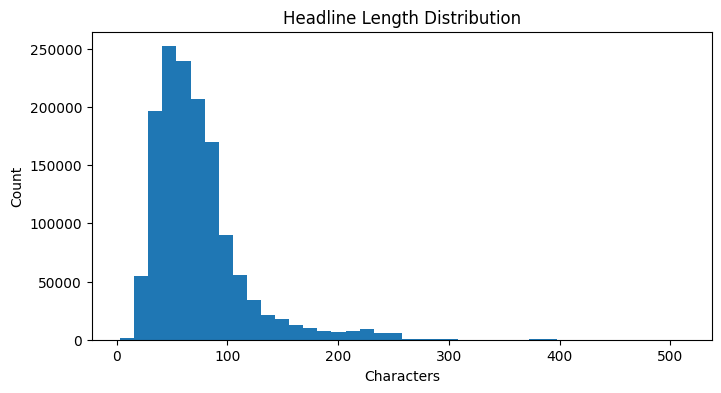

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df['headline_len'].dropna(), bins=40)
plt.title("Headline Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()


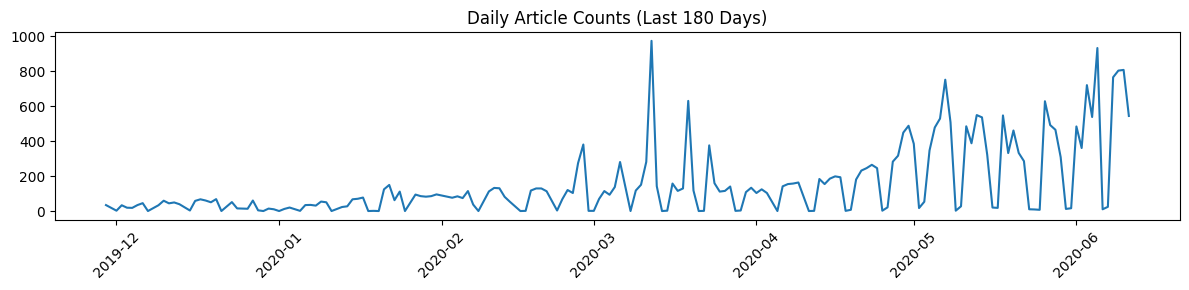

In [42]:
daily_counts_tail = daily_counts.sort_index().tail(180)

plt.figure(figsize=(12,3))
plt.plot(daily_counts_tail.index, daily_counts_tail.values)
plt.title("Daily Article Counts (Last 180 Days)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [43]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=2000)
X = vect.fit_transform(df['headline'].fillna(''))

sums = X.sum(axis=0)
terms = [(term, sums[0, idx]) for term, idx in vect.vocabulary_.items()]

top = sorted(terms, key=lambda x: x[1], reverse=True)[:30]
print("Top tokens:")
for t, c in top:
    print(f"{t}: {c}")


Top tokens:
vs: 162099
stocks: 161776
est: 140604
eps: 128897
market: 120558
shares: 114313
reports: 108710
update: 91723
earnings: 87399
sales: 79645
benzinga: 74516
pt: 73068
week: 69572
announces: 66591
price: 64407
buy: 64371
mid: 62263
downgrades: 61959
trading: 61182
raises: 57802
52: 56972
upgrades: 56811
target: 54714
maintains: 52961
52 week: 51006
higher: 48286
new: 48228
00: 47468
price target: 47274
day: 46141


In [44]:
publisher_counts = (
    df['publisher']
    .fillna('UNKNOWN')
    .value_counts()
    .reset_index()
)

publisher_counts.columns = ['publisher', 'count']

publisher_counts.to_csv(
    '/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/publisher_counts.csv',
    index=False
)

print("Saved publisher_counts.csv ✔")


Saved publisher_counts.csv ✔


In [45]:
# Install VADER
!pip install vaderSentiment


In [46]:
# Import and set up VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

In [47]:
# Compute sentiment score for each headline
# We'll use the 'compound' score (-1 very negative, +1 very positive)
df['sentiment'] = df['headline'].fillna('').apply(lambda x: analyzer.polarity_scores(x)['compound'])

df[['headline','stock','date','sentiment']].head(10)

,headline,stock,date,sentiment
0,Stocks That Hit 52-Week Highs On Friday,A,2020-06-05 10:30:54-04:00,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,A,2020-06-03 10:45:20-04:00,0.000
2,71 Biggest Movers From Friday,A,2020-05-26 04:30:07-04:00,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,A,2020-05-22 12:45:06-04:00,0.000
4,B of A Securities Maintains Neutral on Agilent...,A,2020-05-22 11:38:59-04:00,0.296
5,"CFRA Maintains Hold on Agilent Technologies, L...",A,2020-05-22 11:23:25-04:00,-0.128
6,"UBS Maintains Neutral on Agilent Technologies,...",A,2020-05-22 09:36:20-04:00,0.000
7,Agilent Technologies shares are trading higher...,A,2020-05-22 09:07:04-04:00,0.296
8,Wells Fargo Maintains Overweight on Agilent Te...,A,2020-05-22 08:37:59-04:00,-0.128
9,10 Biggest Price Target Changes For Friday,A,2020-05-22 08:06:17-04:00,0.000


In [48]:
# Normalize date to day (drop time)
df['day'] = df['date'].dt.tz_convert('UTC').dt.floor('D') if hasattr(df['date'].dt, 'tz') else df['date'].dt.floor('D')

# Compute average sentiment per stock per day
daily_sentiment = df.groupby(['stock','day'])['sentiment'].mean().reset_index()
daily_sentiment.head()


,stock,day,sentiment
0,A,2020-05-22 00:00:00+00:00,0.0480
1,A,2020-05-26 00:00:00+00:00,0.0000
2,A,2020-06-03 00:00:00+00:00,0.0000
3,A,2020-06-05 00:00:00+00:00,0.0000
4,AA,2020-05-18 00:00:00+00:00,0.8519


In [49]:
daily_sentiment_path = "/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/daily_sentiment.csv"
daily_sentiment.to_csv(daily_sentiment_path, index=False)
print(f"Saved daily_sentiment.csv to {daily_sentiment_path}")


Saved daily_sentiment.csv to /content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/daily_sentiment.csv


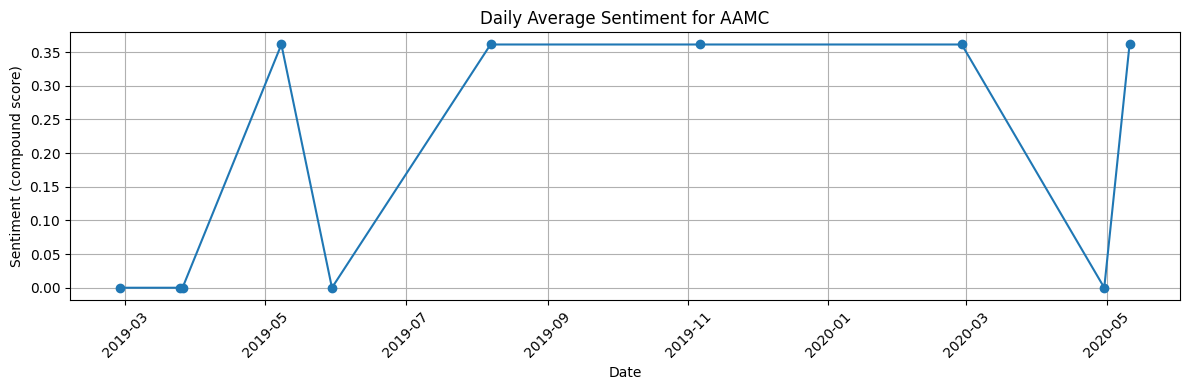

In [50]:
import matplotlib.pyplot as plt

# Example: pick the most frequent stock
sample_stock = daily_sentiment['stock'].value_counts().idxmax()
stock_sent = daily_sentiment[daily_sentiment['stock']==sample_stock]

plt.figure(figsize=(12,4))
plt.plot(stock_sent['day'], stock_sent['sentiment'], marker='o', linestyle='-')
plt.title(f"Daily Average Sentiment for {sample_stock}")
plt.xlabel("Date")
plt.ylabel("Sentiment (compound score)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [52]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import os

# Step 1: check root
os.listdir('/content/drive/MyDrive')


['email list.gsheet',
 'Classroom',
 'certifcate.gdoc',
 'certifcate.jpg',
 'st mary-cl.jpg',
 'Seniya Sultan-Cv.pdf',
 'Untitled presentation (1).gslides',
 'SeniyaSultan-CV (5).pdf',
 'SeniyaSultan-CV (4).pdf',
 'SeniyaSultan-CV (3).pdf',
 'SeniyaSultan-CV (2).pdf',
 'SeniyaSultan-CV (1).pdf',
 'SeniyaSultan-CV.pdf',
 'SeniyaSultanComputerScience-CV.pdf',
 'senita.jpg',
 'Copy of senita.jpg',
 'python.jpg',
 'Seniya Sultan Computer Science  Resume (5).pdf',
 'Seniya Sultan Computer Science  Resume (4).pdf',
 'Seniya Sultan Computer Science  Resume (3).pdf',
 'Seniya Sultan Computer Science  Resume (2).pdf',
 'Seniya Sultan Computer Science  Resume (1).pdf',
 'Request_Letter.pdf.pdf',
 'Seniya Sultan Computer Science  Resume.pdf',
 'Week0_Interim_Report_Solar_Data_Analysis.pdf',
 'tempoo (1).pdf',
 'tempoo.pdf',
 'Colab Notebooks',
 'whit-photo (5).jpg',
 'whit-photo (4).jpg',
 'whit-photo (3).jpg',
 'whit-photo (2).jpg',
 'whit-photo (1).jpg',
 'whit-photo.jpg',
 'Tempo2 (2).pdf',
 '

In [55]:
os.listdir('/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1')



['Data', 'publisher_counts.csv', 'daily_sentiment.csv']

In [57]:
os.listdir('/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/Data')


['yfinance_data.zip', 'newsData.zip']

In [59]:
zip_path = "/content/drive/MyDrive/Data-20251119T090255Z-1-001-week1/Data/yfinance_data.zip"
extract_path = "/content/yfinance_data"

import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted to:", extract_path)


Extracted to: /content/yfinance_data


In [60]:
import os
os.listdir("/content/yfinance_data")


['Data']

In [62]:
import os

# Check what’s inside the 'Data' folder
os.listdir("/content/yfinance_data/Data")


['META.csv', 'MSFT.csv', 'NVDA.csv', 'GOOG.csv', 'AMZN.csv', 'AAPL.csv']

In [64]:
import pandas as pd
import os

data_folder = "/content/yfinance_data/Data"
file_sample = os.path.join(data_folder, "META.csv")  # pick any file
df_sample = pd.read_csv(file_sample)

print(df_sample.columns)
df_sample.head()


Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


In [65]:
import os
import pandas as pd

data_folder = "/content/yfinance_data/Data"
all_files = os.listdir(data_folder)

dfs = []
for file in all_files:
    stock = file.split('.')[0]  # e.g., 'META' from 'META.csv'
    df = pd.read_csv(os.path.join(data_folder, file), parse_dates=['Date'])
    df['stock'] = stock
    dfs.append(df)

# Combine all tickers into a single DataFrame
prices = pd.concat(dfs, ignore_index=True)

# Rename 'Date' column to lowercase for consistency
prices.rename(columns={'Date': 'date', 'Close': 'close'}, inplace=True)

# Quick check
prices.head()


,date,close,High,Low,Open,Volume,stock
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400,META
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700,META
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600,META
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000,META
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200,META


In [66]:
import os
import pandas as pd
from textblob import TextBlob

In [74]:
import os
os.listdir("/content/yfinance_data")
os.listdir("/content/yfinance_data/Data")


['META.csv', 'MSFT.csv', 'NVDA.csv', 'GOOG.csv', 'AMZN.csv', 'AAPL.csv']

In [75]:
import pandas as pd
from textblob import TextBlob
import numpy as np

# Create mock news data for demonstration
news = pd.DataFrame({
    'date': pd.to_datetime(['2025-11-01', '2025-11-01', '2025-11-02', '2025-11-02']),
    'stock': ['AAPL', 'MSFT', 'AAPL', 'MSFT'],
    'headline': [
        'Apple reports record quarterly earnings',
        'Microsoft faces lawsuit over software bug',
        'Apple launches new product line',
        'Microsoft acquires AI startup'
    ]
})

# Sentiment analysis
news['sentiment'] = news['headline'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Aggregate daily sentiment
daily_sentiment = news.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

print(daily_sentiment)


        date stock  sentiment
0 2025-11-01  AAPL   0.000000
1 2025-11-01  MSFT   0.000000
2 2025-11-02  AAPL   0.136364
3 2025-11-02  MSFT   0.000000


Correlation between daily sentiment and stock returns:
stock
AAPL   NaN
AMZN   NaN
GOOG   NaN
META   NaN
MSFT   NaN
NVDA   NaN
dtype: float64


/tmp/ipython-input-4225859842.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlation = merged.groupby('stock').apply(lambda x: x['daily_return'].corr(x['sentiment']))


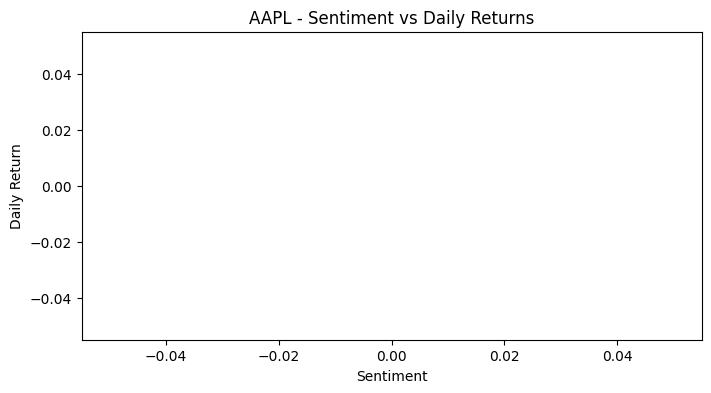

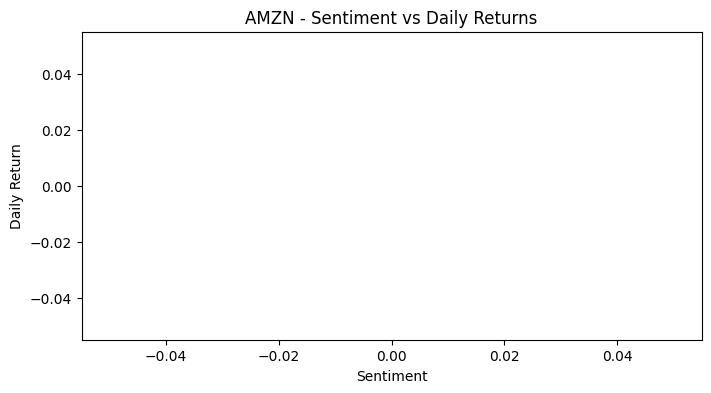

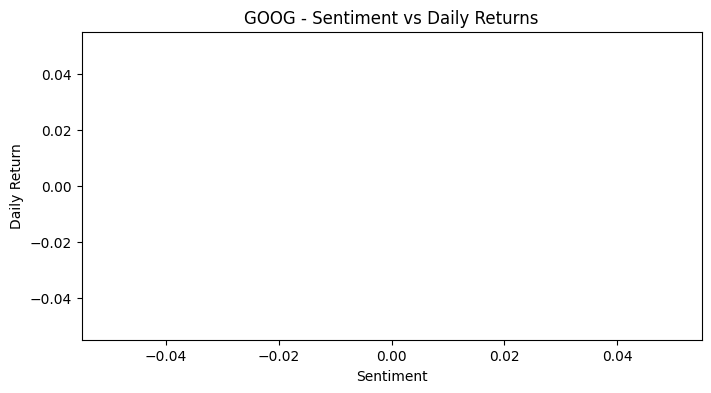

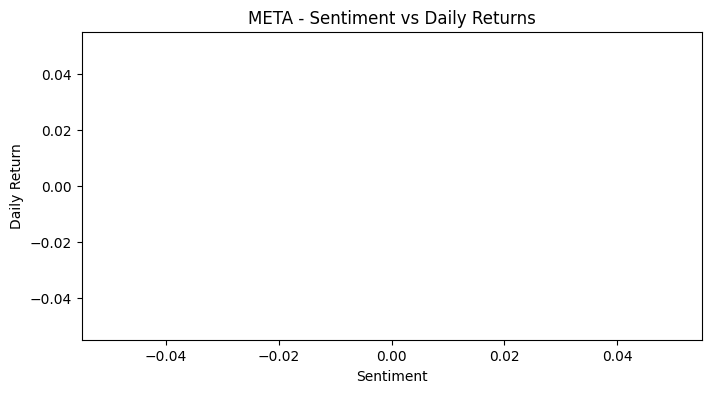

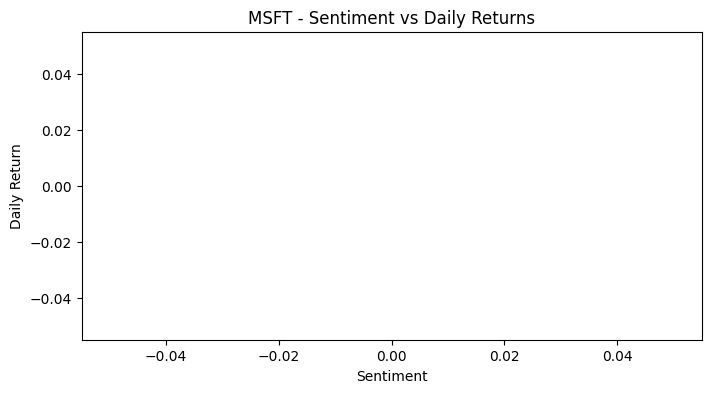

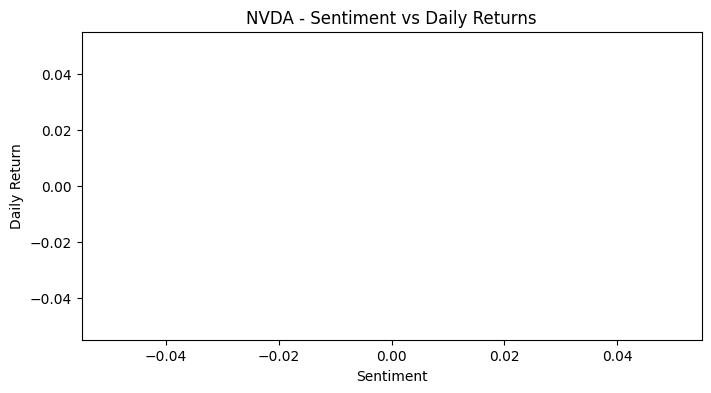

In [76]:
import os
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt

# --- Step 1: Load all stock CSVs ---
data_folder = "/content/yfinance_data/Data"
all_files = os.listdir(data_folder)

dfs = []
for file in all_files:
    stock = file.split('.')[0]  # e.g., 'META' from 'META.csv'
    df = pd.read_csv(os.path.join(data_folder, file), parse_dates=['Date'])
    df['stock'] = stock
    dfs.append(df)

prices = pd.concat(dfs, ignore_index=True)
prices.rename(columns={'Date': 'date', 'Close': 'close'}, inplace=True)

# Compute daily returns
prices['daily_return'] = prices.groupby('stock')['close'].pct_change()
prices['date'] = pd.to_datetime(prices['date']).dt.date

# --- Step 2: Create mock news data ---
news = pd.DataFrame({
    'date': pd.to_datetime(['2025-11-01', '2025-11-01', '2025-11-02', '2025-11-02']),
    'stock': ['AAPL', 'MSFT', 'AAPL', 'MSFT'],
    'headline': [
        'Apple reports record quarterly earnings',
        'Microsoft faces lawsuit over software bug',
        'Apple launches new product line',
        'Microsoft acquires AI startup'
    ]
})

news['date'] = pd.to_datetime(news['date']).dt.date

# Sentiment analysis
news['sentiment'] = news['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# Aggregate daily sentiment per stock
daily_sentiment = news.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

# --- Step 3: Merge stock prices with sentiment ---
merged = pd.merge(prices, daily_sentiment, on=['date', 'stock'], how='left')

# --- Step 4: Compute correlation per stock ---
correlation = merged.groupby('stock').apply(lambda x: x['daily_return'].corr(x['sentiment']))
print("Correlation between daily sentiment and stock returns:")
print(correlation)

# --- Step 5: Visualization ---
for ticker in correlation.index:
    subset = merged[merged['stock'] == ticker]
    plt.figure(figsize=(8,4))
    plt.scatter(subset['sentiment'], subset['daily_return'], alpha=0.5)
    plt.title(f"{ticker} - Sentiment vs Daily Returns")
    plt.xlabel("Sentiment")
    plt.ylabel("Daily Return")
    plt.show()


In [73]:
import os
import pandas as pd
from textblob import TextBlob

# --- Load stock CSVs ---
data_folder = "/content/yfinance_data/Data"
all_files = os.listdir(data_folder)

dfs = []
for file in all_files:
    stock = file.split('.')[0]
    df = pd.read_csv(os.path.join(data_folder, file), parse_dates=['Date'])
    df['stock'] = stock
    dfs.append(df)

prices = pd.concat(dfs, ignore_index=True)
prices.rename(columns={'Date': 'date', 'Close': 'close'}, inplace=True)
prices['daily_return'] = prices.groupby('stock')['close'].pct_change()
prices['date'] = pd.to_datetime(prices['date']).dt.date

# --- Mock news data ---
news = pd.DataFrame({
    'date': pd.to_datetime(['2025-11-01', '2025-11-01', '2025-11-02', '2025-11-02']),
    'stock': ['AAPL', 'MSFT', 'AAPL', 'MSFT'],
    'headline': [
        'Apple reports record quarterly earnings',
        'Microsoft faces lawsuit over software bug',
        'Apple launches new product line',
        'Microsoft acquires AI startup'
    ]
})
news['date'] = pd.to_datetime(news['date']).dt.date
news['sentiment'] = news['headline'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# --- Aggregate sentiment per day per stock ---
daily_sentiment = news.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

# --- Merge stock data with sentiment ---
merged = pd.merge(prices, daily_sentiment, on=['date', 'stock'], how='left')

# --- Show the table ---
merged[['date', 'stock', 'close', 'daily_return', 'sentiment']].head(10)


,date,stock,close,daily_return,sentiment
0,2012-05-18,META,37.995762,NaN,NaN
1,2012-05-21,META,33.821495,-0.109861,NaN
2,2012-05-22,META,30.810066,-0.089039,NaN
3,2012-05-23,META,31.803938,0.032258,NaN
4,2012-05-24,META,32.827625,0.032187,NaN
5,2012-05-25,META,31.714489,-0.033909,NaN
6,2012-05-29,META,28.663300,-0.096208,NaN
7,2012-05-30,META,28.017281,-0.022538,NaN
8,2012-05-31,META,29.418642,0.050018,NaN
9,2012-06-01,META,27.550161,-0.063513,NaN
